<a href="https://colab.research.google.com/github/SimbakNetmind/machine-learnig-curos/blob/Machine_learning/01_A_Regresion_Lineal_Teoria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **01- Importar Librerias**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (12,12)
plt.rcParams['font.size'] = 16

# **02- Cargar DataFrame**

In [ ]:
df = pd.read_csv("sample_data/vehiculos_procesado.csv",
                 usecols=["consumo", "co2", "cilindros","desplazamiento"])

print(f'Cantidad de filas: {df.shape[0]}')
print(f'Cantidad de columnas: {df.shape[1]}')
df.head(5)

Cantidad de filas: 35539
Cantidad de columnas: 4


,desplazamiento,cilindros,consumo,co2
0,2.5,4.0,17,522.764706
1,4.2,6.0,13,683.615385
2,2.5,4.0,16,555.437500
3,4.2,6.0,13,683.615385
4,3.8,6.0,16,555.437500


# **03- Copia de DataFrame**

In [ ]:
vehiculos = df.copy()

# **04- Litros por Milla**

In [ ]:
litros_por_galon =  3.78541
vehiculos["consumo_litros_milla"] = litros_por_galon/ vehiculos.consumo
vehiculos.head(5)

,desplazamiento,cilindros,consumo,co2,consumo_litros_milla
0,2.5,4.0,17,522.764706,0.222671
1,4.2,6.0,13,683.615385,0.291185
2,2.5,4.0,16,555.437500,0.236588
3,4.2,6.0,13,683.615385,0.291185
4,3.8,6.0,16,555.437500,0.236588


# **05- El modelo de regresión lineal mediante OLS (ordinary least squares) tiene la forma:**

$$ \hat{y} = \alpha + \beta_{1}*x_{1} + \beta_{2}*x_{2} + ... + \beta_{n}*x_{n} + \varepsilon$$

Donde $\hat{y}$ es la predicción que queremos hacer,

$\alpha$ es el término independiente,

$\beta_{n}$ es un vector de coeficientes
y $x_{n}$ son los valores de las variables del dataset.

El objetivo es obtener $\alpha$ y $\beta_{n}$  tales que error cuadrático (residuo) , definido como:

$$RSS = \varepsilon² = \sum\limits_{i=1}^n(y_{i} - (\alpha - \beta_{i}x_{i}))^2$$

sea el mínimo.

Para ello tenemos que resolver las siguientes equaciones

$$\hat{\alpha} = \bar{y} - \hat{\beta}*\bar{x}$$
$$\hat{\beta} = (X^TX)^{-1}X^Ty$$

# Suma de Cuadrados Residuales (RSS)

La **Suma de Cuadrados Residuales** (*Residual Sum of Squares*, **RSS**) o **Suma de Errores al Cuadrado** (**SSE**) mide la discrepancia total entre los valores observados y las predicciones de un modelo de regresión.

$$RSS = \varepsilon^2 = \sum_{i=1}^{n} \left( y_i - (\alpha + \beta x_i) \right)^2$$

---

### Componentes de la fórmula

* **$y_i$:** Valor real u observado.
* **$\alpha + \beta x_i$:** Valor predicho por el modelo ($\hat{y}_i$).
* **$y_i - \hat{y}_i$:** Residuo o error de la observación $i$.
* **$\sum (\dots)^2$:** Eleva los errores al cuadrado (evitando cancelaciones entre positivos y negativos) y los suma para las $n$ observaciones.

---

### Objetivo en Regresión Lineal
En el método de **Mínimos Cuadrados Ordinarios (OLS)**, el objetivo es encontrar los parámetros $\alpha$ y $\beta$ que **minimicen** el valor del $RSS$.

# Estimación de Parámetros en Regresión Lineal

---

### 1. Intersección u Origen ($\hat{\alpha}$)
Mide el valor estimado del término independiente (intercepto) en una regresión lineal simple.

$$\hat{\alpha} = \bar{y} - \hat{\beta} * \bar{x}$$

**Variables:**
* **$\hat{\alpha}$:** Intercepto u origen estimado.
* **$\bar{y}$:** Media (promedio) de la variable respuesta $y$.
* **$\hat{\beta}$:** Pendiente estimada de la recta de regresión.
* **$\bar{x}$:** Media (promedio) de la variable predictora $x$.

---

### 2. Estimador OLS Matricial ($\hat{\beta}$)
Calcula el vector de coeficientes estimados mediante Mínimos Cuadrados Ordinarios usando álgebra matricial.

$$\hat{\beta} = (X^T X)^{-1} X^T y$$

**Variables:**
* **$\hat{\beta}$:** Vector de coeficientes o pesos estimados del modelo.
* **$X$:** Matriz de diseño (datos de entrada/características).
* **$X^T$:** Transpuesta de la matriz $X$.
* **$(X^T X)^{-1}$:** Inversa de la matriz $(X^T X)$.
* **$y$:** Vector de valores observados de la variable dependiente.

# **06- Datos de Entranamiento y Test**

Para obtener los coeficientes del modelo dedicamos una fracción del dataset a entrenar y otra a evaluar los resultados (para evitar sobreajuste o sobregeneralización)

In [ ]:
pct_entrenamiento = 0.8

vehiculos_training = vehiculos.sample(frac=pct_entrenamiento)


vehiculos_test = vehiculos[~vehiculos.index.isin(vehiculos_training.index)]

print(f'Datos Entrenamiento: {vehiculos_training.shape}')
print(f'Datos Pureba:  {vehiculos_test.shape}')


Datos Entrenamiento: (28431, 5)
Datos Pureba:  (7108, 5)


# **07- Vectorizar DataFrame**

In [ ]:
variables_independientes = ['desplazamiento', 'cilindros', 'consumo_litros_milla']
variable_dependiente = 'co2'

# Opción recomendada (pandas moderno):
x = vehiculos_training[variables_independientes].to_numpy()
y = vehiculos_training[variable_dependiente].to_numpy()

X_T = x.T
print("Matrix: X \n")
print(x)
print("Shape: ")
print(x.shape)
print("\n Matrix: Y \n")
print(y)
print("Shape: ")
print(y.shape)
print("\n Traspuesta de X \n")
print(X_T)
print("Shape: ")
print(X_T.shape)
#

Matrix: X 

[[2.2        4.         0.21030056]
 [3.         6.         0.18025762]
 [2.5        4.         0.15772542]
 ...
 [2.4        4.         0.16458304]
 [4.3        6.         0.23658813]
 [3.8        6.         0.21030056]]
Shape: 
(28431, 3)

 Matrix: Y 

[493.72222222 426.         370.29166667 ... 386.39130435 555.4375
 493.72222222]
Shape: 
(28431,)

 Traspuesta de X 

[[2.2        3.         2.5        ... 2.4        4.3        3.8       ]
 [4.         6.         4.         ... 4.         6.         6.        ]
 [0.21030056 0.18025762 0.15772542 ... 0.16458304 0.23658813 0.21030056]]
Shape: 
(3, 28431)


# 📐  **08. Estimador OLS Matricial ($\hat{\beta}$)**
Calcula el vector de coeficientes estimados mediante Mínimos Cuadrados Ordinarios usando álgebra matricial.

Este bloque resume la resolución analítica de la **Regresión Lineal Múltiple** mediante Mínimos Cuadrados Ordinarios (OLS).
$$\hat{\beta} = (X^T X)^{-1} X^T y$$

---

## 💻 Código

```python
# Cálculo de los coeficientes óptimos (betas)
betas = np.linalg.inv(X_T @ X) @ X_T @ y

In [ ]:
betas = np.linalg.inv(X_T @ x) @ X_T @ y
betas

array([ 3.60440152e+00, -4.96233709e-01,  2.30538169e+03])

# 📊 **09 - Media Aritmética (`y.mean()`)**

El método `y.mean()` calcula el **promedio aritmético** de los valores contenidos en la variable dependiente $y$ (en este caso, las emisiones de `co2`).

---

## 🔬 Fórmula Matemática

$$\bar{y} = \frac{1}{n} \sum_{i=1}^{n} y_i$$

---

<!-- ## 🎯 Utilidad en Regresión Lineal

1. **Predicción Base (Modelo Nulo):** Es la mejor predicción simple posible para cualquier vehículo si no tuviéramos variables independientes ($X$).
2. **Evaluación del Modelo ($R^2$):** Se utiliza para medir la **Suma Total de Cuadrados** ($SS_{\text{tot}}$) y determinar cuánto reduce el error nuestro modelo frente a predecir siempre la media:

$$SS_{\text{tot}} = \sum_{i=1}^{n} (y_i - \bar{y})^2$$ -->

In [ ]:
y.mean()

np.float64(470.9884619716008)

# 🎯 **10-Cálculo del Intercepto o Sesgo (`alfa`)**

### 1. Intersección u Origen ($\hat{\alpha}$)
Mide el valor estimado del término independiente (intercepto) en una regresión lineal simple.

$$\hat{\alpha} = \bar{y} - \hat{\beta} * \bar{x}$$

---

## 💻 Código en Python

```python
# Corrección moderna sin .as_matrix():
alfa = y.mean() - np.dot(betas, vehiculos_training[variables_independientes].mean().to_numpy())

In [ ]:
alfa = y.mean() - np.dot(betas,vehiculos_training[variables_independientes].mean().to_numpy())
alfa

np.float64(0.3605782635264063)

# **11- Metodo de predicción**

Este código define la función para calcular la predicción del modelo y la aplica a cada fila del conjunto de datos (tanto de entrenamiento como de prueba).

In [ ]:
def predecir(r):
    return alfa + np.dot(betas, r.values)

# **12. Aplicación a los conjuntos de datos (.apply(...))**

axis=1: Le indica a Pandas que ejecute la función predecir fila por fila (auto por auto), en lugar de columna por columna.

    Crea una nueva columna llamada co2_pred tanto en el dataset de entrenamiento (vehiculos_training) como en el de prueba (vehiculos_test) para almacenar los valores predichos.

⚠️ Sobre la advertencia (SettingWithCopyWarning)

Ves ese aviso amarillo porque vehiculos_test probablemente se creó filtrando otro DataFrame. Pandas te advierte que podrías estar modificando una copia y no el DataFrame original.

Forma más eficiente y rápida en NumPy (sin .apply ni warnings):
En lugar de iterar fila por fila con .apply(), puedes calcular todas las predicciones de un solo golpe usando multiplicación matricial con @ o np.dot:

In [ ]:
# # Mucho más rápido y sin warnings:
# vehiculos_training["co2_pred"] = alfa + vehiculos_training[variables_independientes].to_numpy() @ betas
# vehiculos_test["co2_pred"] = alfa + vehiculos_test[variables_independientes].to_numpy() @ betas

vehiculos_training["co2_pred"] = vehiculos_training[variables_independientes].apply(
    predecir, axis=1)
vehiculos_test["co2_pred"] = vehiculos_test[variables_independientes].apply(predecir, axis=1)

/tmp/ipykernel_653/2936651087.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vehiculos_test["co2_pred"] = vehiculos_test[variables_independientes].apply(predecir, axis=1)


### 🔬 ¿Qué hace este código?

Construye una **cadena de texto legible** que representa la ecuación matemática final ajustada por el modelo de regresión lineal.

* **Inyección de valores:** Inserta el intercepto (`alfa`) y cada coeficiente (`betas[0]`, `betas[1]`, `betas[2]`) en la fórmula general.
* **Formato numérico:**
  * `:.3f`: Redondea el valor a **3 decimales** (para `alfa` y `beta_3`).
  * `:.2f`: Redondea el valor a **2 decimales** (para `beta_1` y `beta_2`).

---

### 💡 Resultado final esperable

Genera un *string* explicativo del modelo con los parámetros numéricos reales:

$$\text{co2} = \alpha + \beta_1 \cdot \text{desplazamiento} + \beta_2 \cdot \text{cilindros} + \beta_3 \cdot \text{consumo\_litros\_milla}$$

In [ ]:
model_formula = "y ~ {alfa:.3f} + {beta_1:.2f}*desplazamiento + {beta_2:.2f}*cilindros + {beta_3:.3f}*consumo_litros_milla".format(
    alfa=alfa, beta_1=betas[0], beta_2=betas[1], beta_3=betas[2])
model_formula

'y ~ 0.361 + 3.60*desplazamiento + -0.50*cilindros + 2305.382*consumo_litros_milla'

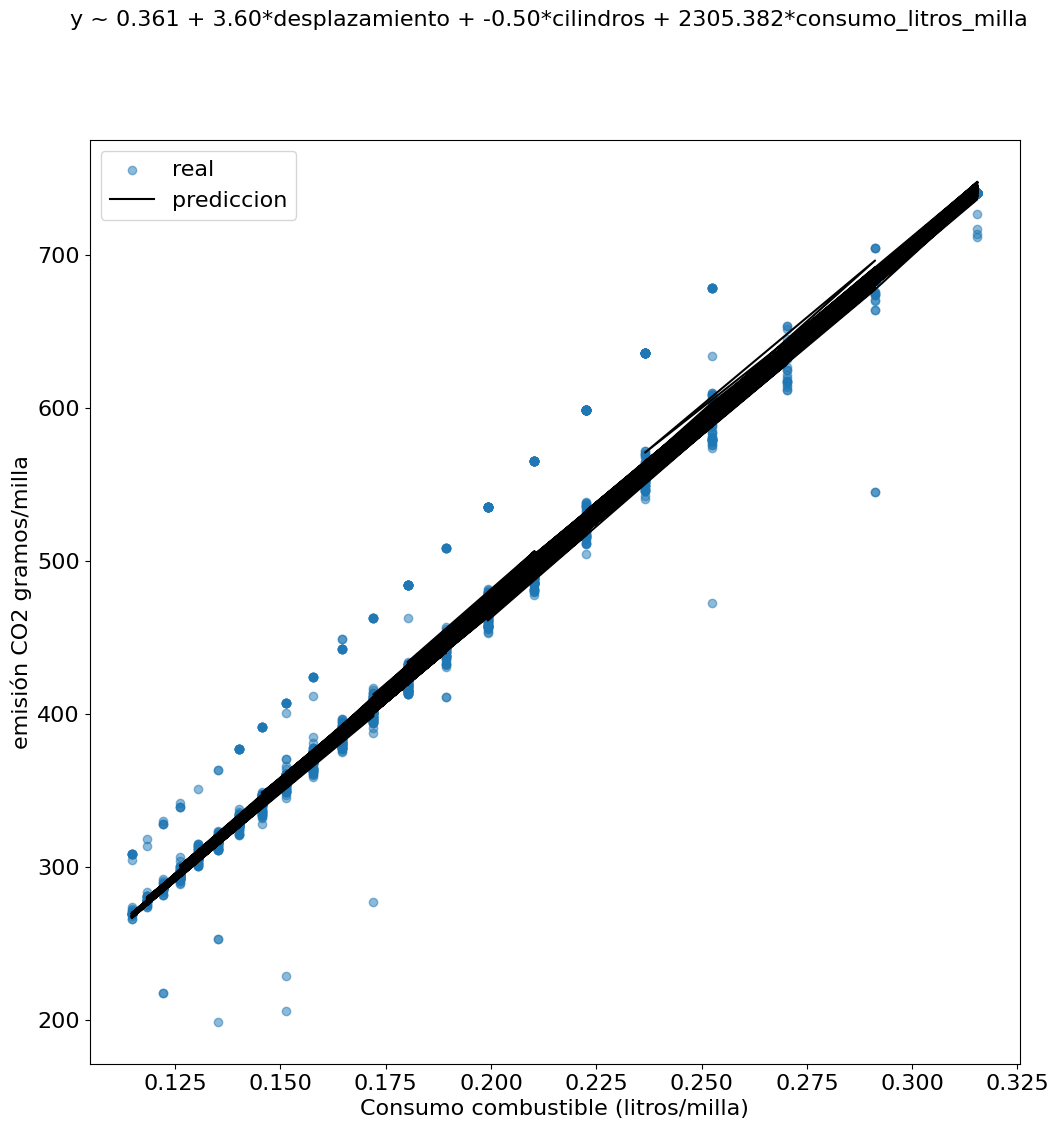

In [ ]:

plt.scatter(vehiculos_test.consumo_litros_milla, vehiculos_test.co2, alpha=0.5, label="real")
plt.text(0.1, 850, model_formula)
plt.plot(vehiculos_test.consumo_litros_milla,vehiculos_test.co2_pred, c="black", label="prediccion")
plt.xlabel("Consumo combustible (litros/milla)")
plt.ylabel("emisión CO2 gramos/milla")
plt.legend();

# **14- Errorers Cuadrantes**

La **Suma de Cuadrados Residuales** (*Residual Sum of Squares*, **RSS**) o **Suma de Errores al Cuadrado** (**SSE**) mide la discrepancia total entre los valores observados y las predicciones de un modelo de regresión.

$$RSS = \varepsilon^2 = \sum_{i=1}^{n} \left( y_i - (\alpha + \beta x_i) \right)^2$$

In [ ]:
def error_cuadrático_medio(y, y_pred):
    return np.sum((y-y_pred)**2)/len(y)

In [ ]:
error_training = error_cuadrático_medio(vehiculos_training.co2, vehiculos_training.co2_pred)
error_training

np.float64(133.58819839152292)

In [ ]:
error_test = error_cuadrático_medio(vehiculos_test.co2, vehiculos_test.co2_pred)
error_test

np.float64(122.09037296417266)

In [ ]:
predicion_error = error_training -error_test
predicion_error

np.float64(11.497825427350264)

In [ ]:
numero =error_test
raiz = numero ** 0.5
print(raiz)  # 11.04943437464654

11.049451251721628


# 📊 **Análisis de los Resultados: Error Cuadrático Medio (MSE)**

Hemos calculado el **Error Cuadrático Medio (MSE)** para nuestros dos conjuntos de datos:
* **Entrenamiento (`error_training`):** $133.59$
* **Prueba (`error_test`):** $122.09$

¿Qué nos dicen exactamente estos números?

#### 1. Magnitud del Error y RMSE
El MSE mide el **promedio de los errores al cuadrado** entre las emisiones de $\text{CO}_2$ reales y las predicciones de nuestro modelo. Para entender este error en las unidades reales de $\text{CO}_2$ (y no al cuadrado), calculamos la Raíz del Error Cuadrático Medio (**RMSE**):

$$\text{RMSE}_{test} = \sqrt{122.09} \approx 11.05$$

> **Interpretación:** Nuestro modelo se equivoca, en promedio, por aproximadamente **$11.05$ unidades de $\text{CO}_2$** al predecir datos nuevos.

#### 2. Generalización: Training vs. Test
* **No hay *overfitting* (sobreajuste):** Observamos que el error de prueba ($122.09$) es ligeramente menor que el de entrenamiento ($133.59$).
* Esto es una excelente señal. Confirma que el modelo generaliza bien y ha aprendido los patrones subyacentes de los datos, en lugar de aprenderse "de memoria" los datos de entrenamiento. La ligera mejora en el set de prueba suele darse cuando esa muestra tiene menos valores atípicos (*outliers*) o menos "ruido" que la de entrenamiento.

---
**💡 Conclusión:** El modelo presenta una excelente salud estadística. No sufre de sobreajuste y tiene un margen de error de aproximadamente $11$ unidades de $\text{CO}_2$ en la práctica.